In [31]:
import pandas as pad
import numpy as np
import matplotlib.pyplot as plt
import requests

In [32]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [33]:
df.head()

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [34]:
df.shape

(19402, 4)

In [35]:
japon = df[df['entity'] == 'Japan']

In [36]:
mexico = df[df['entity'] == 'Mexico']

In [37]:
japon.head()

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225


In [38]:
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [39]:
anios_mexico = mexico['year'].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon['year'].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [40]:
type(anios_mexico), type(tasa_mexico)

(numpy.ndarray, numpy.ndarray)

In [41]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

In [42]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)

minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

In [43]:
print(f"Promedio México: {promedio_mexico}")
print(f"Máximo México: {maximo_mexico}")
print(f"Mínimo México: {minimo_mexico}")
print(f"Desviación estándar México: {desviacion_mexico}")

Promedio México: 4.326364864864865
Máximo México: 6.833
Mínimo México: 1.91
Desviación estándar México: 1.8802504834162772


In [44]:
print(f"Promedio Japon: {promedio_japon}")
print(f"Máximo Japon: {maximo_japon}")
print(f"Mínimo Japon: {minimo_japon}")
print(f"Desviación estándar Japon: {desviacion_japon}")

Promedio Japon: 1.8388051948051947
Máximo Japon: 4.614
Mínimo Japon: 1.208
Desviación estándar Japon: 0.7018619770141482


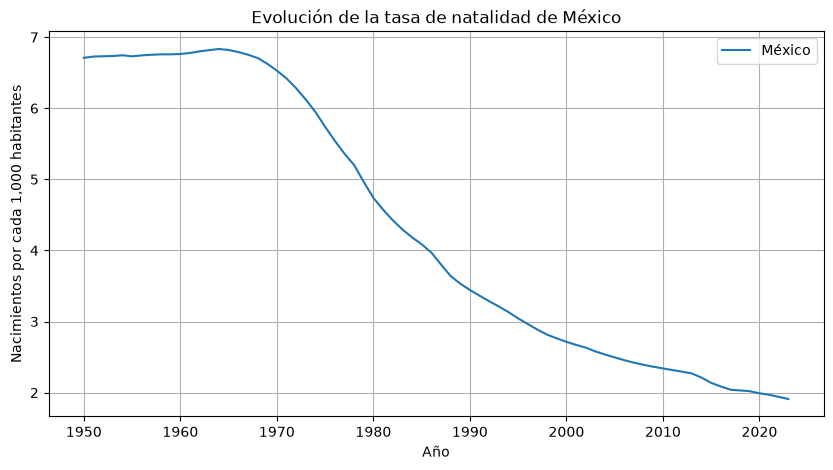

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México",
)

plt.title("Evolución de la tasa de natalidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

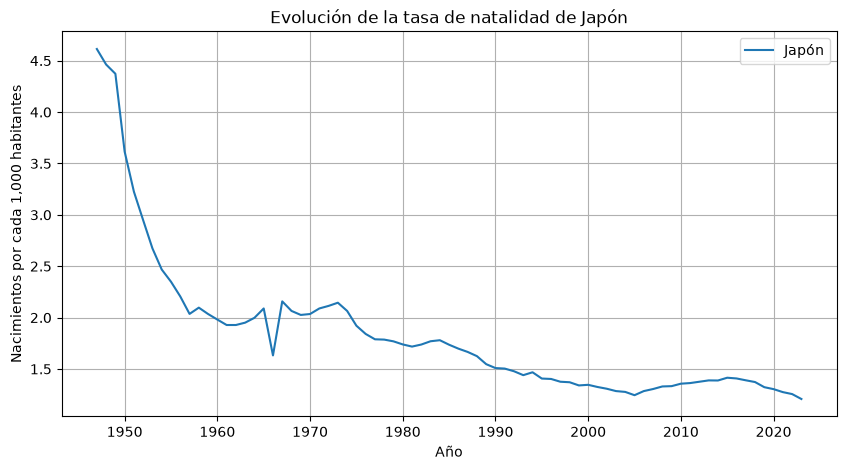

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón",
)

plt.title("Evolución de la tasa de natalidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

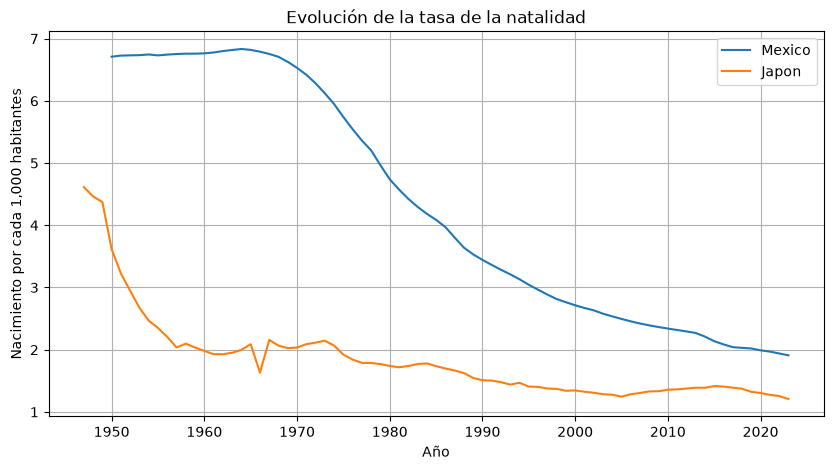

In [47]:
plt.figure(figsize=(10,5))

plt.plot( ##Funciona para graficar utilizando matplot
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot( ##Funciona para graficar utilizando matplot
    anios_japon,
    tasa_japon,
    label="Japon"
)

plt.title("Evolución de la tasa de la natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [48]:
mexico.shape

(74, 4)

In [49]:
japon.shape

(77, 4)

In [50]:
tasa_mexico.shape

(74,)

In [51]:
tasa_japon.shape

(77,)

In [52]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()


In [53]:
mascara_coincidencia_anios


array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [54]:
mascara_coincidencia_anios.shape


(77,)

In [55]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [56]:
anios_japon2 = anios_japon[mascara_coincidencia_anios]

In [57]:
diferencia_mx_jp = tasa_mexico - tasa_japon

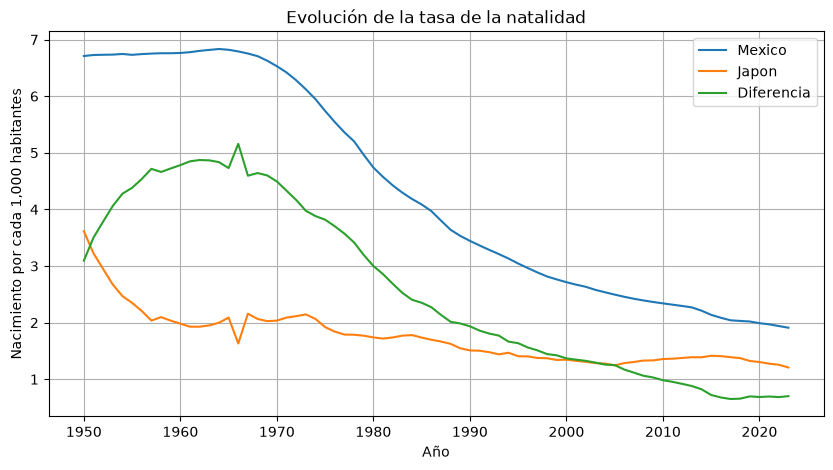

In [58]:
plt.figure(figsize=(10,5))

plt.plot( ##Funciona para graficar utilizando matplot
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot(
    anios_japon2,
    tasa_japon,
    label="Japon"
)

plt.plot(
    anios_mexico, 
    diferencia_mx_jp,
    label="Diferencia"
)

plt.title("Evolución de la tasa de la natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [59]:
brasil = df[(df["entity"] == "Brazil")]

In [60]:
anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["fertility_rate_hist"].to_numpy()

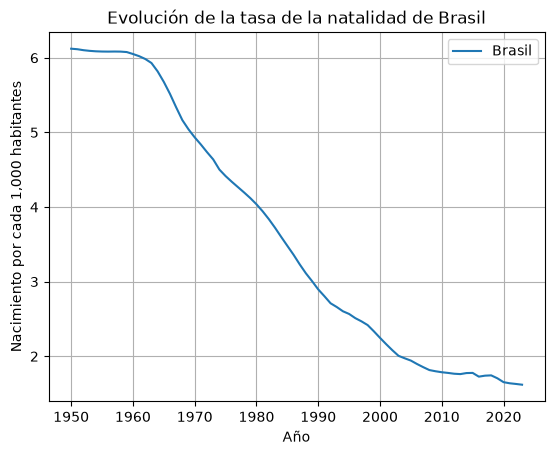

In [61]:
plt.plot( ##Funciona para graficar utilizando matplotblob:vscode-webview://0gs9qme40pbru74eu03li65o5icgm522du823gappqei6ijjof7n/835310b8-f8df-4d3e-b781-a37c282ac580
    anios_brasil,
    tasa_brasil,
    label="Brasil"
)

plt.title("Evolución de la tasa de la natalidad de Brasil")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [62]:
diferencia_mx_br = tasa_mexico - tasa_brasil

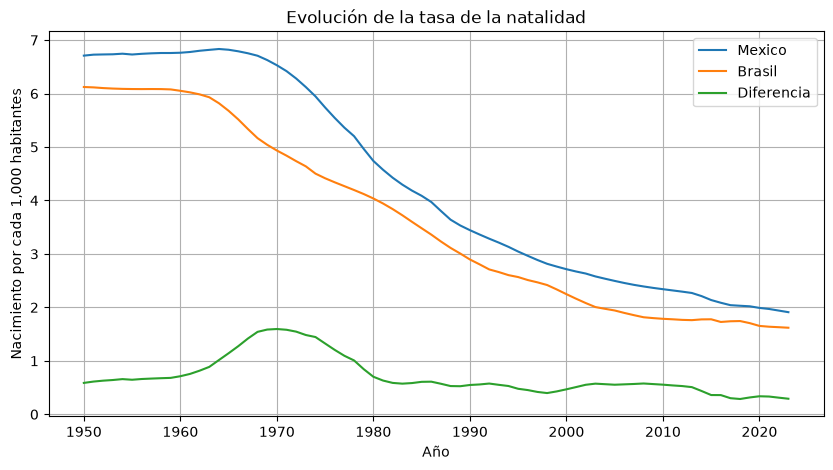

In [63]:
plt.figure(figsize=(10,5))

plt.plot( ##Funciona para graficar utilizando matplot
    anios_mexico,
    tasa_mexico,
    label="Mexico"
)

plt.plot( ##Funciona para graficar utilizando matplot
    anios_brasil,
    tasa_brasil,
    label="Brasil"
)

plt.plot(
    anios_mexico, 
    diferencia_mx_br,
    label="Diferencia"
)

plt.title("Evolución de la tasa de la natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimiento por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [64]:
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [65]:
##Forma de extraer los datos, peraparndolos desde el data frame de pandas

comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    mexico[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [66]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jap_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()

In [67]:
anios_japon3 = np.delete(anios_japon, [])